In [20]:
import jax
import numpy as np
import cotengra as ctg
import quimb.tensor as qtn
import quimb as qu
from concurrent.futures import ThreadPoolExecutor
import sys
import tqdm
from functools import reduce
from itertools import product

In [2]:
def Q_to_Ising(qubo_matrix, O):
    n_qubits = qubo_matrix.shape[0]
    J = {}
    h = {i : 0 for i in range(n_qubits)}
    # zi^2 = 1
    for i in range(n_qubits):
        # Q[i, i]xi^2 = Q[i, i](1 - 2zi + zi^2)/4 -> h[i] = - Q[i, i]/ 2, O += Q[i, i] / 2
        h[i] -= qubo_matrix[i, i] / 2
        O += qubo_matrix[i, i] / 2
        # Calculate pairwise interactions
        for j in range(i + 1, n_qubits):
            # Q[i, j]xi xj = Q[i, j] (1 - zi - zj + zi zj)/4 -> J[i, j] = Q[i, j] / 4, h[i], h[j] -= Q[i, j]/4, O+= Q[i, j] / 4
            J[(i, j)] = qubo_matrix[i, j] / 4
            h[i] -= qubo_matrix[i, j] / 4
            h[j] -= qubo_matrix[i, j] / 4
            O += qubo_matrix[i, j] / 4
    return h, J, O

In [3]:
data = np.load('/lustre/scratch127/qpg/jc59/out/tangle/qubo_data_trivial.gfa.npy', allow_pickle=True)
Q, offset, T, W = data

In [4]:
path = [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0]

In [5]:
path @ Q @ path + offset

np.float64(0.0)

In [6]:
QQ = np.triu(Q) * 2
QQ -= np.triu(np.triu(QQ).T) / 2
h, J, new_offset = Q_to_Ising(QQ, offset)

In [7]:
def energy_Ising(z, h, J, O):
    """
    Calculate the energy of an Ising model given spin configurations.

    Parameters:
    - z: A dictionary representing the spin configurations for each qubit.
    - h: A dictionary representing the magnetic fields for each qubit.
    - J: A dictionary representing the pairwise interactions between qubits.
    - offset: An offset value.

    Returns:
    - energy: The total energy of the Ising model.
    """
    # Initialize the energy with the offset term
    energy = O
    # Loop over the magnetic fields (h) for each qubit and update the energy
    for k, v in h.items():
        energy += v * z[k]
    # Loop over the pairwise interactions (J) between qubits and update the energy
    for k, v in J.items():
        energy += v * z[k[0]] * z[k[1]]
    # Return the total energy of the Ising model
    return energy

In [8]:
path_z = [1 if x == 0 else -1 for x in path]

In [9]:
energy_Ising(path_z, h, J, new_offset)

np.float64(0.0)

In [84]:
p = 8

In [85]:
res, res_O = np.load(f'/lustre/scratch127/qpg/jc59/out/cotengra/non_local_exp_data_p_{p}_trivial.gfa.npy', allow_pickle=True)

In [86]:
x  = res.x
gammas = x[:p]
betas = x[p:]
circ = qtn.circ_qaoa(h, J, p, gammas, betas)
state = circ.psi.to_dense(to_ket='True')


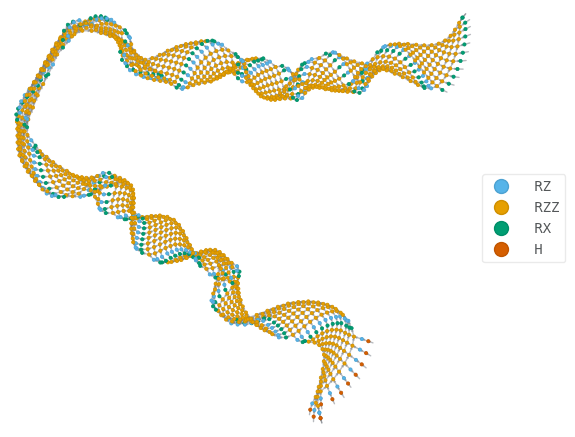

In [83]:
V = circ.uni
V.draw(color=['RZ', 'RZZ', 'RX', 'H'])

In [87]:
counts = qu.calc.simulate_counts(state, 2 ** 20)

In [88]:
sorted_counts = (sorted(counts.items(), key=lambda item: item[1], reverse=True))

In [73]:
z = [(-1) ** int(x) for x in sorted_counts[0][0]]
print(energy_Ising(z, h, J, new_offset))
xx = [int(x) for x in sorted_counts[0][0]]
xx @ Q @ xx + offset

107.0


np.float64(107.0)

In [74]:
z = [(-1) ** int(x) for x in sorted_counts[1][0]]
print(energy_Ising(z, h, J, new_offset))
xx = [int(x) for x in sorted_counts[1][0]]
xx @ Q @ xx + offset

47.0


np.float64(47.0)

In [89]:
print(counts['100001000010'])
z = [(-1) ** int(x) for x in '100001000010']
print(energy_Ising(path_z, h, J, new_offset))
xx = [int(x) for x in '100001000010']
xx @ Q @ xx + offset

3757
0.0


np.float64(0.0)

In [90]:
3757 / (2 ** 20)

0.0035829544067382812

In [91]:
2 ** 12

4096

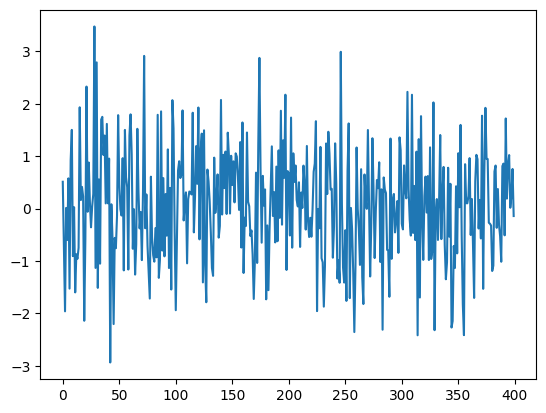

In [76]:
from matplotlib import pyplot as plt

plt.plot(res.func_vals)

In [35]:
# This is possibly very slow
N_vars = Q.shape[0]
d = 2 ** N_vars
H = np.zeros((d, d), dtype=complex)
for edge, weight in list(J.items()):
    Z_op = np.diagflat([(-1) ** (i[edge[0]] + i[edge[1]]) for i in product([0, 1], repeat=N_vars)])
    H += weight * Z_op
for i, weight in list(h.items()):
    Z_op = np.diagflat([(-1) ** (j[i]) for j in product([0, 1], repeat=N_vars)])
    H += weight * Z_op
H = qu.qarray(H)

In [77]:
qu.expectation(state, H)

np.float64(-2.947560495602562)

In [78]:
sol_state = qu.computational_state('100001000010')

In [66]:
qu.expectation(sol_state, H)

np.float64(-110.5)

<Axes: title={'center': 'Convergence plot'}, xlabel='Number of calls $n$', ylabel='$\\min f(x)$ after $n$ calls'>

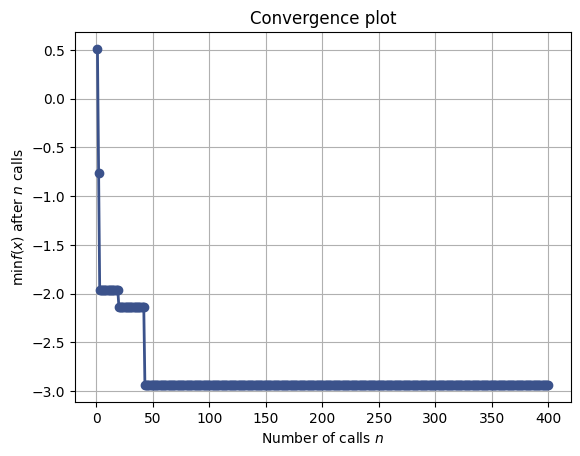

In [79]:
from skopt.plots import plot_convergence, plot_objective
plot_convergence(res)

<Axes: >

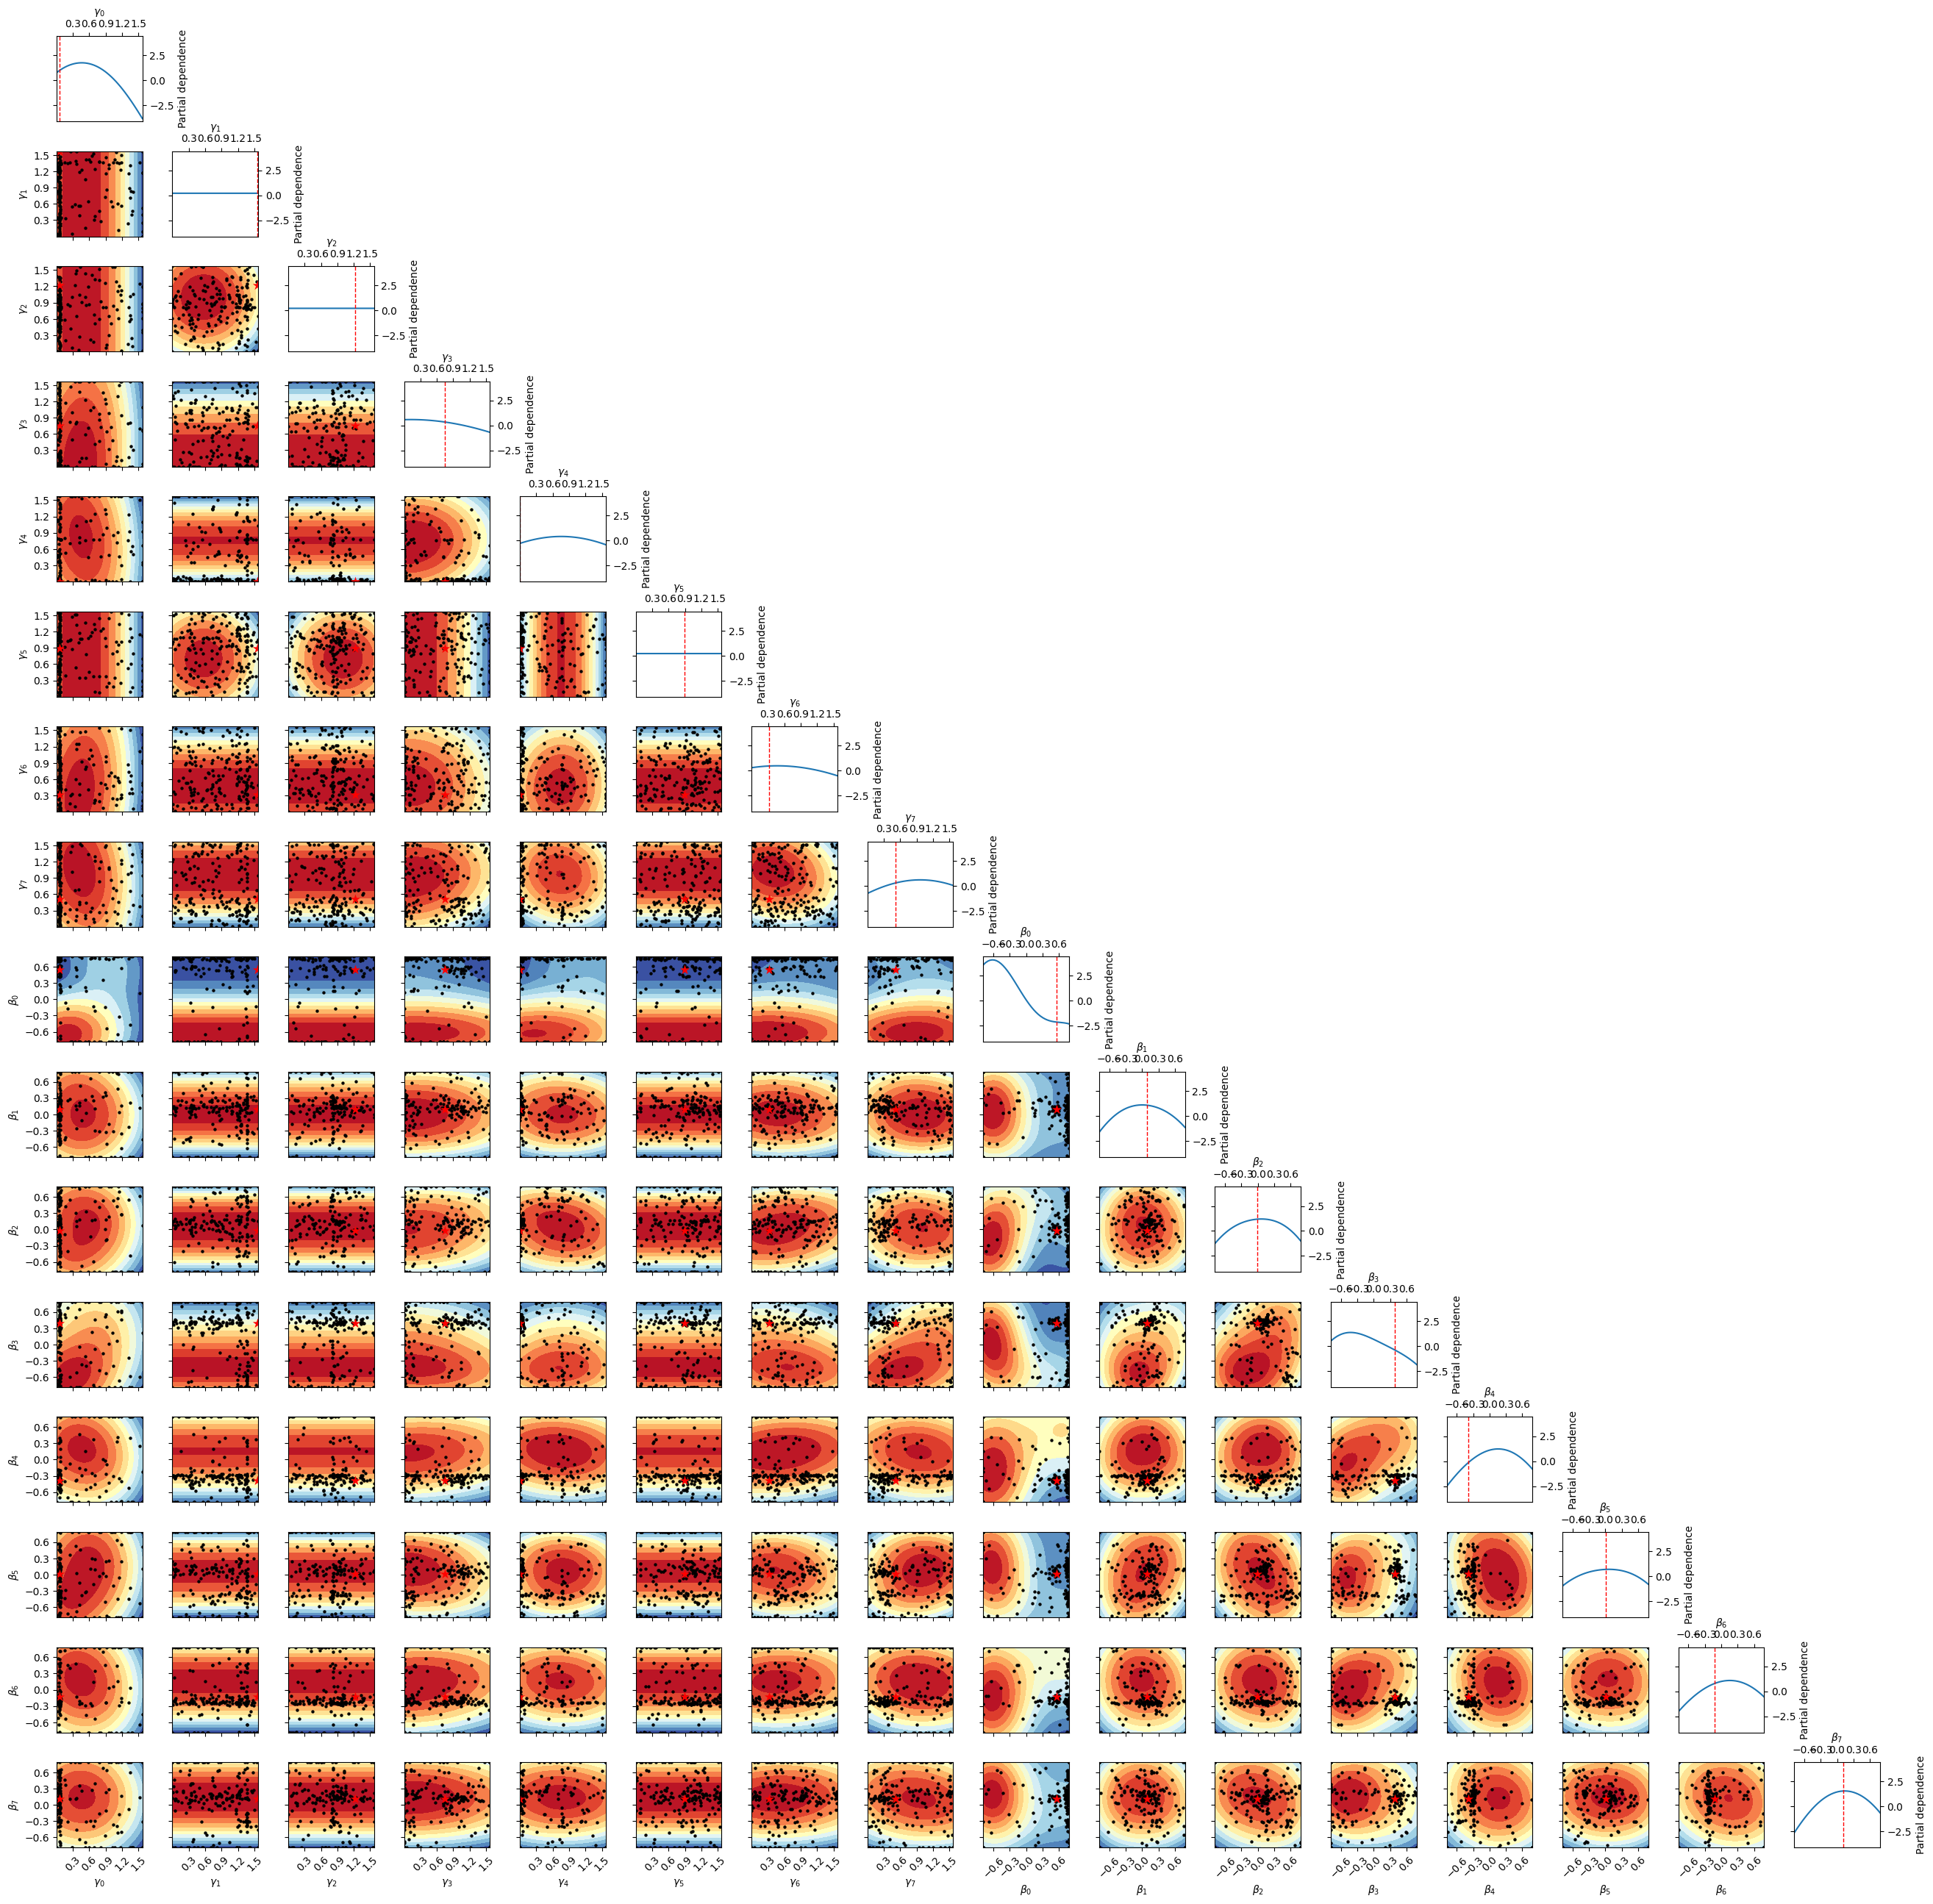

In [25]:
plot_objective(
        res,
        cmap='RdYlBu_r',
        dimensions=[f'$\\gamma_{i}$' for i in range(p)] + [f'$\\beta_{i}$' for i in range(p)],
    )

In [55]:
len(res.x)

64